# Teoría y Aplicación de Naive Bayes en Análisis Marino-Costero

## Objetivos del Módulo
- Comprender el teorema de Bayes y su aplicación en machine learning
- Diferenciar entre GaussianNB, MultinomialNB y BernoulliNB
- Aplicar clasificadores Naive Bayes a problemas de calidad de agua marina
- Evaluar modelo utilizando validación cruzada

## Contexto Marino-Costero
Los clasificadores Naive Bayes son eficientes para clasificar:
- Calidad del agua (buena/regular/pobre) basada en parámetros físico-químicos
- Presencia de contaminación marina
- Tipo de ecosistema marino
- Estado de salud del arrecife de coral


## Teorema de Bayes

El Teorema de Bayes es el fundamento matemático de los clasificadores Naive Bayes:

$$P(C|X) = \frac{P(X|C) \cdot P(C)}{P(X)}$$

Donde:
- **P(C|X)**: Probabilidad posterior (probability of class C given features X)
- **P(X|C)**: Verosimilitud (likelihood of features given class)
- **P(C)**: Probabilidad a priori (prior probability of class)
- **P(X)**: Evidencia (probability of observing features)

### Suposición "Naive" (Ingenua)
Naive Bayes asume que todas las características son **independientes condicionalmente** dado la clase.
Aunque esta suposición es frecuentemente violada en datos reales, el algoritmo funciona sorprendentemente bien.

## Tipos de Naive Bayes

### GaussianNB
- **Uso**: Características continuas
- **Suposición**: Características siguen distribución normal
- **Fórmula**: P(X_i|C) = (1/√(2πσ²)) * exp(-(X_i - μ)² / (2σ²))
- **Aplicación marina**: Calidad del agua con parámetros continuos (temperatura, salinidad, pH)

### MultinomialNB
- **Uso**: Conteos de características (e.g., frecuencias de palabras en textos)
- **Suposición**: Características son no-negativas (conteos)
- **Aplicación marina**: Clasificación de imágenes oceanográficas, análisis de texto de reportes

### BernoulliNB
- **Uso**: Características binarias (presencia/ausencia)
- **Suposición**: Cada característica es 0 o 1
- **Aplicación marina**: Presencia/ausencia de especies indicadoras, contaminantes


Naive Bayes is a family of probabilistic classifiers based on applying Bayes' theorem with strong (naive) independence assumptions between the features. This means that the effect of a feature on a class is assumed to be independent of the values of the other features.

Despite this seemingly oversimplified assumption, naive Bayes classifiers have been very successful in many complex real-world situations, such as spam filtering and document classification.

There are various types of Naive Bayes classifiers, including:

Gaussian Naive Bayes: This assumes that the continuous values associated with each class are distributed according to a Gaussian (or normal) distribution.

Multinomial Naive Bayes: This is used for multiclass classification tasks and assumes that the features are multinomially distributed.

Bernoulli Naive Bayes: This is similar to Multinomial Naive Bayes but is used when the data is binary (i.e., has only two possible outcomes).

The Naive Bayes algorithm involves estimating the parameters of the probability distributions for each feature, given the class, using techniques such as maximum likelihood estimation. Then, given a new instance to classify, the algorithm calculates the posterior probability of each class, given the instance, using Bayes' theorem. The class with the highest posterior probability is then chosen as the predicted class.

Here's an example of how to use Naive Bayes in Python using scikit-learn:

In [1]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)

# Example 1: Iris Dataset (for learning purposes)
# This classic dataset demonstrates the classifier before applying to marine data
print("=" * 60)
print("Ejemplo 1: Dataset Iris (para propósitos educativos)")
print("=" * 60)

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Split data
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris,
    test_size=0.2,
    random_state=42,
    stratify=y_iris
)

# Train Naive Bayes
nb_iris = GaussianNB()
nb_iris.fit(X_train_iris, y_train_iris)

# Evaluate
y_pred_iris = nb_iris.predict(X_test_iris)
accuracy_iris = accuracy_score(y_test_iris, y_pred_iris)
print(f"\nIris Dataset - Accuracy: {accuracy_iris:.4f}")

# Cross-validation
cv_scores = cross_val_score(nb_iris, X_iris, y_iris, cv=5, scoring='accuracy')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Example 2: Simulated Marine Water Quality Data (Continuous Features)
print("\n" + "=" * 60)
print("Ejemplo 2: Datos Simulados de Calidad del Agua Marina")
print("=" * 60)

# Simulate water quality data
n_samples = 200
np.random.seed(42)

# Simulate three water quality classes: Good, Regular, Poor
# Features: Temperature, Salinity, pH, Dissolved Oxygen, Nitrate Level

# Good quality water
temperatura_good = np.random.normal(20, 2, n_samples // 3)
salinidad_good = np.random.normal(35, 1, n_samples // 3)
pH_good = np.random.normal(8.1, 0.2, n_samples // 3)
ox_disuelto_good = np.random.normal(8.5, 0.5, n_samples // 3)
nitratos_good = np.random.normal(2, 1, n_samples // 3)

# Regular quality water
temperatura_regular = np.random.normal(24, 3, n_samples // 3)
salinidad_regular = np.random.normal(33, 2, n_samples // 3)
pH_regular = np.random.normal(7.8, 0.3, n_samples // 3)
ox_disuelto_regular = np.random.normal(6.5, 0.8, n_samples // 3)
nitratos_regular = np.random.normal(5, 1.5, n_samples // 3)

# Poor quality water
temperatura_poor = np.random.normal(28, 2, n_samples // 3)
salinidad_poor = np.random.normal(30, 2, n_samples // 3)
pH_poor = np.random.normal(7.2, 0.4, n_samples // 3)
ox_disuelto_poor = np.random.normal(4, 1, n_samples // 3)
nitratos_poor = np.random.normal(9, 2, n_samples // 3)

# Combine data
X_marina = np.vstack([
    np.column_stack([temperatura_good, salinidad_good, pH_good, ox_disuelto_good, nitratos_good]),
    np.column_stack([temperatura_regular, salinidad_regular, pH_regular, ox_disuelto_regular, nitratos_regular]),
    np.column_stack([temperatura_poor, salinidad_poor, pH_poor, ox_disuelto_poor, nitratos_poor])
])

y_marina = np.hstack([
    np.full(n_samples // 3, 0),  # Good
    np.full(n_samples // 3, 1),  # Regular
    np.full(n_samples // 3, 2)   # Poor
])

# Create DataFrame
datos_marina = pd.DataFrame(X_marina, columns=[
    "Temperatura(°C)", "Salinidad(PSU)", "pH", "O2_Disuelto(mg/L)", "Nitratos(mg/L)"
])
datos_marina["Calidad"] = pd.Categorical(
    y_marina,
    categories=[0, 1, 2],
    ordered=False
)
datos_marina["Calidad"] = datos_marina["Calidad"].map({
    0: "Buena",
    1: "Regular",
    2: "Pobre"
})

print("\nDatos de Calidad del Agua Marina (primeras 5 filas):")
print(datos_marina.head())
print(f"\nDistribución de clases:")
print(datos_marina["Calidad"].value_counts())

# Prepare data
X = datos_marina[["Temperatura(°C)", "Salinidad(PSU)", "pH", "O2_Disuelto(mg/L)", "Nitratos(mg/L)"]]
y = datos_marina["Calidad"]

# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTamaño del conjunto de entrenamiento: {X_train.shape[0]}")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]}")


Ejemplo 1: Dataset Iris (para propósitos educativos)

Iris Dataset - Accuracy: 0.9667
Cross-validation scores: [0.93333333 0.96666667 0.93333333 0.93333333 1.        ]
Mean CV Accuracy: 0.9533 (+/- 0.0267)

Ejemplo 2: Datos Simulados de Calidad del Agua Marina

Datos de Calidad del Agua Marina (primeras 5 filas):
   Temperatura(°C)  Salinidad(PSU)        pH  O2_Disuelto(mg/L)  \
0        20.993428       34.927990  7.887539           8.529104   
1        19.723471       36.003533  8.194718           7.928515   
2        21.295377       35.361636  7.916115           8.678894   
3        23.046060       34.354880  8.409987           8.780392   
4        19.531693       35.361396  7.943349           9.041526   

   Nitratos(mg/L) Calidad  
0        1.747432   Buena  
1        0.752217   Buena  
2        3.632411   Buena  
3        0.569859   Buena  
4        1.559956   Buena  

Distribución de clases:
Calidad
Buena      66
Regular    66
Pobre      66
Name: count, dtype: int64

Tamaño del c


Accuracy (Precisión) del modelo: 1.0000

Reporte de Clasificación:
              precision    recall  f1-score   support

       Buena       1.00      1.00      1.00        13
     Regular       1.00      1.00      1.00        13
       Pobre       1.00      1.00      1.00        14

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


Matriz de Confusión:
[[13  0  0]
 [ 0 14  0]
 [ 0  0 13]]


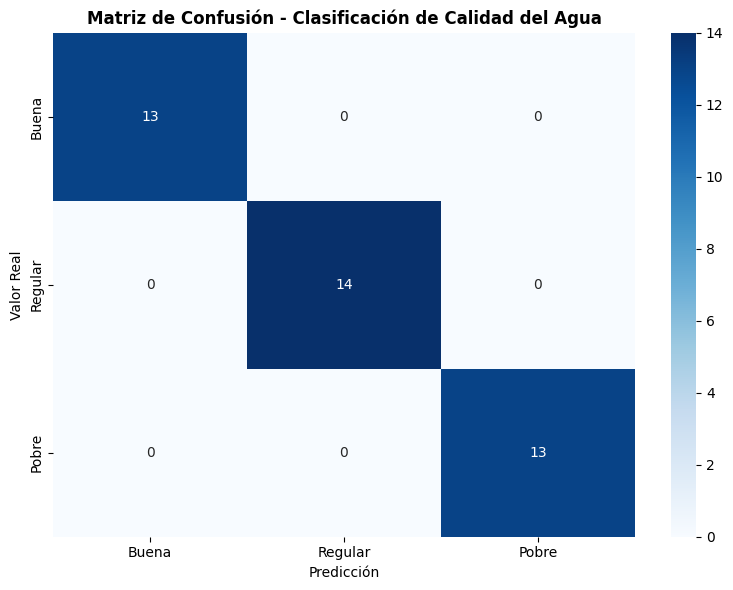

In [2]:
# Train Gaussian Naive Bayes (appropriate for continuous water quality data)
nb_marino = GaussianNB()
nb_marino.fit(X_train, y_train)

# Predictions
y_pred = nb_marino.predict(X_test)
y_pred_proba = nb_marino.predict_proba(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy (Precisión) del modelo: {accuracy:.4f}")

# Classification report
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["Buena", "Regular", "Pobre"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["Buena", "Regular", "Pobre"])
print("\nMatriz de Confusión:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Buena", "Regular", "Pobre"],
            yticklabels=["Buena", "Regular", "Pobre"])
plt.title("Matriz de Confusión - Clasificación de Calidad del Agua", fontweight='bold')
plt.ylabel("Valor Real")
plt.xlabel("Predicción")
plt.tight_layout()
plt.show()


Validación Cruzada (5-Fold)

Scores de validación cruzada: [0.95       0.975      1.         0.94871795 0.97435897]
Accuracy promedio: 0.9696
Desviación estándar: 0.0190


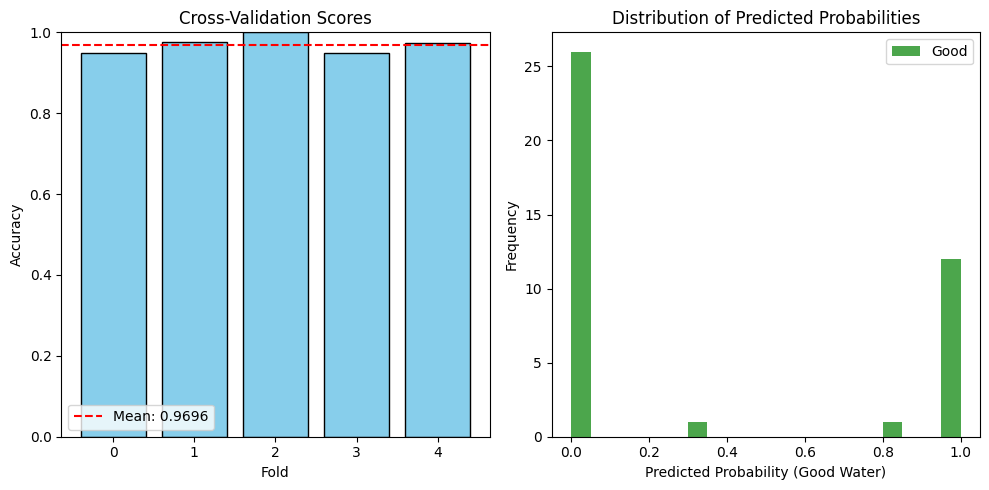

In [3]:
# ============================================================
# PASO: VALIDACIÓN CRUZADA (K-FOLD CROSS VALIDATION)
# ============================================================
# La validación cruzada estima qué tan bien generaliza el modelo a datos no vistos.
# Con K-Fold Cross Validation:
#   1. Los datos se dividen en K grupos (folds) iguales
#   2. En cada iteración, un fold es el conjunto de prueba y los K-1 restantes son entrenamiento
#   3. Se reporta el promedio y desviación estándar de los K scores
# VENTAJA: Usa todos los datos tanto para entrenamiento como para evaluación.
# cv=5: 5 folds → 80% entrenamiento, 20% prueba en cada iteración

print("=" * 60)
print("VALIDACIÓN CRUZADA (5-Fold Cross Validation)")
print("=" * 60)

# GaussianNB() asume que cada feature sigue distribución Normal (Gaussiana).
# cross_val_score re-entrena el modelo en cada fold automáticamente.
cv_scores = cross_val_score(
    GaussianNB(),   # Modelo Naive Bayes Gaussiano
    X, y,           # Matriz de features y etiquetas completas
    cv=5,           # 5 pliegues (folds)
    scoring='accuracy'  # Métrica: fracción de predicciones correctas
)

print(f"\nScores por fold: {[f'{s:.4f}' for s in cv_scores]}")
print(f"Accuracy promedio:  {cv_scores.mean():.4f}  ({cv_scores.mean()*100:.1f}%)")
print(f"Desviación estándar: {cv_scores.std():.4f}")
print()
print("INTERPRETACIÓN:")
print(f"  {'✓ Modelo estable' if cv_scores.std() < 0.05 else '⚠ Alta variabilidad entre folds'}")
print(f"  Intervalo confianza 95%: [{cv_scores.mean()-2*cv_scores.std():.4f}, {cv_scores.mean()+2*cv_scores.std():.4f}]")

# ============================================================
# VISUALIZACIONES: SCORES Y DISTRIBUCIÓN DE PROBABILIDADES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Scores por fold (barras)
# Permite detectar si hay folds donde el modelo falla consistentemente (sesgo en datos)
axes[0].bar(range(1, len(cv_scores)+1), cv_scores, color='steelblue', edgecolor='k', alpha=0.8)
axes[0].axhline(cv_scores.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Media: {cv_scores.mean():.4f}')
axes[0].set_xlabel('Fold (iteración)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Scores de Validación Cruzada por Fold', fontweight='bold')
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')

# Gráfico 2: Distribución de probabilidades predichas
# Muestra qué tan seguro es el modelo en sus predicciones.
# Un modelo calibrado debería tener distribución bimodal (confianza alta cerca de 0 y 1).
proba_buena = y_pred_proba[:, 0]  # Probabilidad de la clase 0 (ej. "Buena calidad de agua")
axes[1].hist(proba_buena, bins=20, alpha=0.8, color='mediumseagreen', edgecolor='k')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Umbral de decisión (0.5)')
axes[1].set_xlabel('Probabilidad Predicha (Clase: Buena Calidad)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Probabilidades Predichas', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print()
print("NOTA: Probabilidades cercanas a 0 o 1 indican alta confianza del modelo.")
print("Probabilidades cercanas a 0.5 indican casos ambiguos difíciles de clasificar.")


this example, we load the iris dataset, split it into training and testing sets, create a Gaussian Naive Bayes classifier, train it on the training set, and use it to predict the classes of the testing set. We then print the number of misclassified instances.

**Explicación de la Técnica Naive Bayes**
Naive Bayes es un clasificador probabilístico basado en el Teorema de Bayes. La idea principal es predecir la clase de una instancia dada sus características. Es llamado "naive" porque asume que las características son independientes entre sí, lo cual raramente es cierto en la práctica, pero aún así puede ser muy efectivo en muchos escenarios.

**Pasos del Algoritmo:**
Calcular las probabilidades a priori de cada clase.
Calcular la probabilidad de cada característica dada cada clase.
Aplicar el Teorema de Bayes para calcular la probabilidad posterior de la clase dada una instancia.
Fórmula del Teorema de Bayes:
𝑃
(
𝐶
∣
𝑋
)
=
𝑃
(
𝑋
∣
𝐶
)
⋅
𝑃
(
𝐶
)
𝑃
(
𝑋
)
P(C∣X)=
P(X)
P(X∣C)⋅P(C)
​


𝑃
(
𝐶
∣
𝑋
)
P(C∣X): Probabilidad de la clase
𝐶
C dado el vector de características
𝑋
X.
𝑃
(
𝑋
∣
𝐶
)
P(X∣C): Probabilidad del vector de características
𝑋
X dado la clase
𝐶
C.
𝑃
(
𝐶
)
P(C): Probabilidad a priori de la clase
𝐶
C.
𝑃
(
𝑋
)
P(X): Probabilidad del vector de características
𝑋
X.
Supuestos del Naive Bayes
Independencia de las Características: Cada característica contribuye de manera independiente a la probabilidad de la clase.
Distribución de Probabilidades: Las probabilidades condicionadas
𝑃
(
𝑋
𝑖
∣
𝐶
)
P(X
i
​
 ∣C) se calculan asumiendo una distribución específica, a menudo gaussiana para datos continuos.

**Caso de Estudio:** Gestión Marino Costero

**Contexto del Caso de Estudio:**

Imaginemos que estamos trabajando con un dataset de calidad del agua en una región costera, donde queremos clasificar la calidad del agua en dos categorías: "Buena" y "Mala", basándonos en varias mediciones (pH, temperatura, concentración de nitratos, etc.).

**Dataset Simulado:**

Vamos a crear un dataset simulado con las siguientes columnas:

pH
Temperatura
Nitratos
Clasificación (Buena/Mala)

Explicación del Código
Cargar Librerías: e1071 para Naive Bayes y caret para partición de datos y evaluación.
Crear Dataset Simulado: Generamos datos aleatorios para pH, Temperatura y Nitratos, con una clasificación aleatoria.
Dividir Datos: Usamos createDataPartition para dividir el dataset en entrenamiento (80%) y prueba (20%).
Entrenar Modelo: Creamos un modelo de Naive Bayes con naiveBayes.
Predecir y Evaluar: Realizamos predicciones sobre el conjunto de prueba y evaluamos el modelo con confusionMatrix

In [4]:
# Import necessary libraries
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import pandas as pd

# Create simulated dataset
np.random.seed(123)
n = 200
data = pd.DataFrame({
    'pH': np.random.normal(loc=7, scale=0.5, size=n),
    'Temperatura': np.random.normal(loc=20, scale=5, size=n),
    'Nitratos': np.random.normal(loc=5, scale=1, size=n),
    'Clasificacion': np.random.choice(['Buena', 'Mala'], size=n)
})

# Split into training and testing sets
X = data.drop('Clasificacion', axis=1)
y = data['Clasificacion']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Train Naive Bayes model
modelo_nb = GaussianNB()
modelo_nb.fit(X_train, y_train)

# Make predictions on testing set
predicciones = modelo_nb.predict(X_test)

# Evaluate the model
print(confusion_matrix(y_test, predicciones))

# Visualize the confusion matrix
print(pd.crosstab(predicciones, y_test, rownames=['Predicted'], colnames=['Actual']))

[[ 8 11]
 [ 5 16]]
Actual     Buena  Mala
Predicted             
Buena          8     5
Mala          11    16


## Ejercicios para el Estudiante

### Ejercicio 1: Comparación de Clasificadores Naive Bayes
Entrena los tres tipos de Naive Bayes (GaussianNB, MultinomialNB, BernoulliNB) en el dataset Iris.
¿Cuál tiene mejor desempeño? ¿Por qué?

**Pista**: Primero necesitarás normalizar los datos para MultinomialNB y BernoulliNB.

```python
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.preprocessing import MinMaxScaler

# Tu código aquí
```

### Ejercicio 2: Análisis de Confianza de Predicción
Para una muestra nueva de agua, obtén las probabilidades predichas para cada clase.
¿Qué significa si la probabilidad para la clase "Buena" es 0.95 vs 0.51?

```python
# Nueva muestra: Temperatura=22, Salinidad=35, pH=8.0, O2=8, Nitratos=1.5
muestra_nueva = np.array([[22, 35, 8.0, 8, 1.5]])
probabilidades = nb_marino.predict_proba(muestra_nueva)
```

### Ejercicio 3: Impacto de Características
¿Cuál característica es más importante para predecir la calidad del agua?
Entrena modelos usando subconjuntos de características y compara accuracy.

```python
# Prueba con diferentes combinaciones de características
# Ejemplo: solo Temperatura y pH
# Compara accuracy con todas las características
```
